<a href="https://colab.research.google.com/github/mmetee/python_2026/blob/main/Hilbert_sine_wave_backtest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install TA-Lib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 40.0 MB/s eta 0:00:00


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


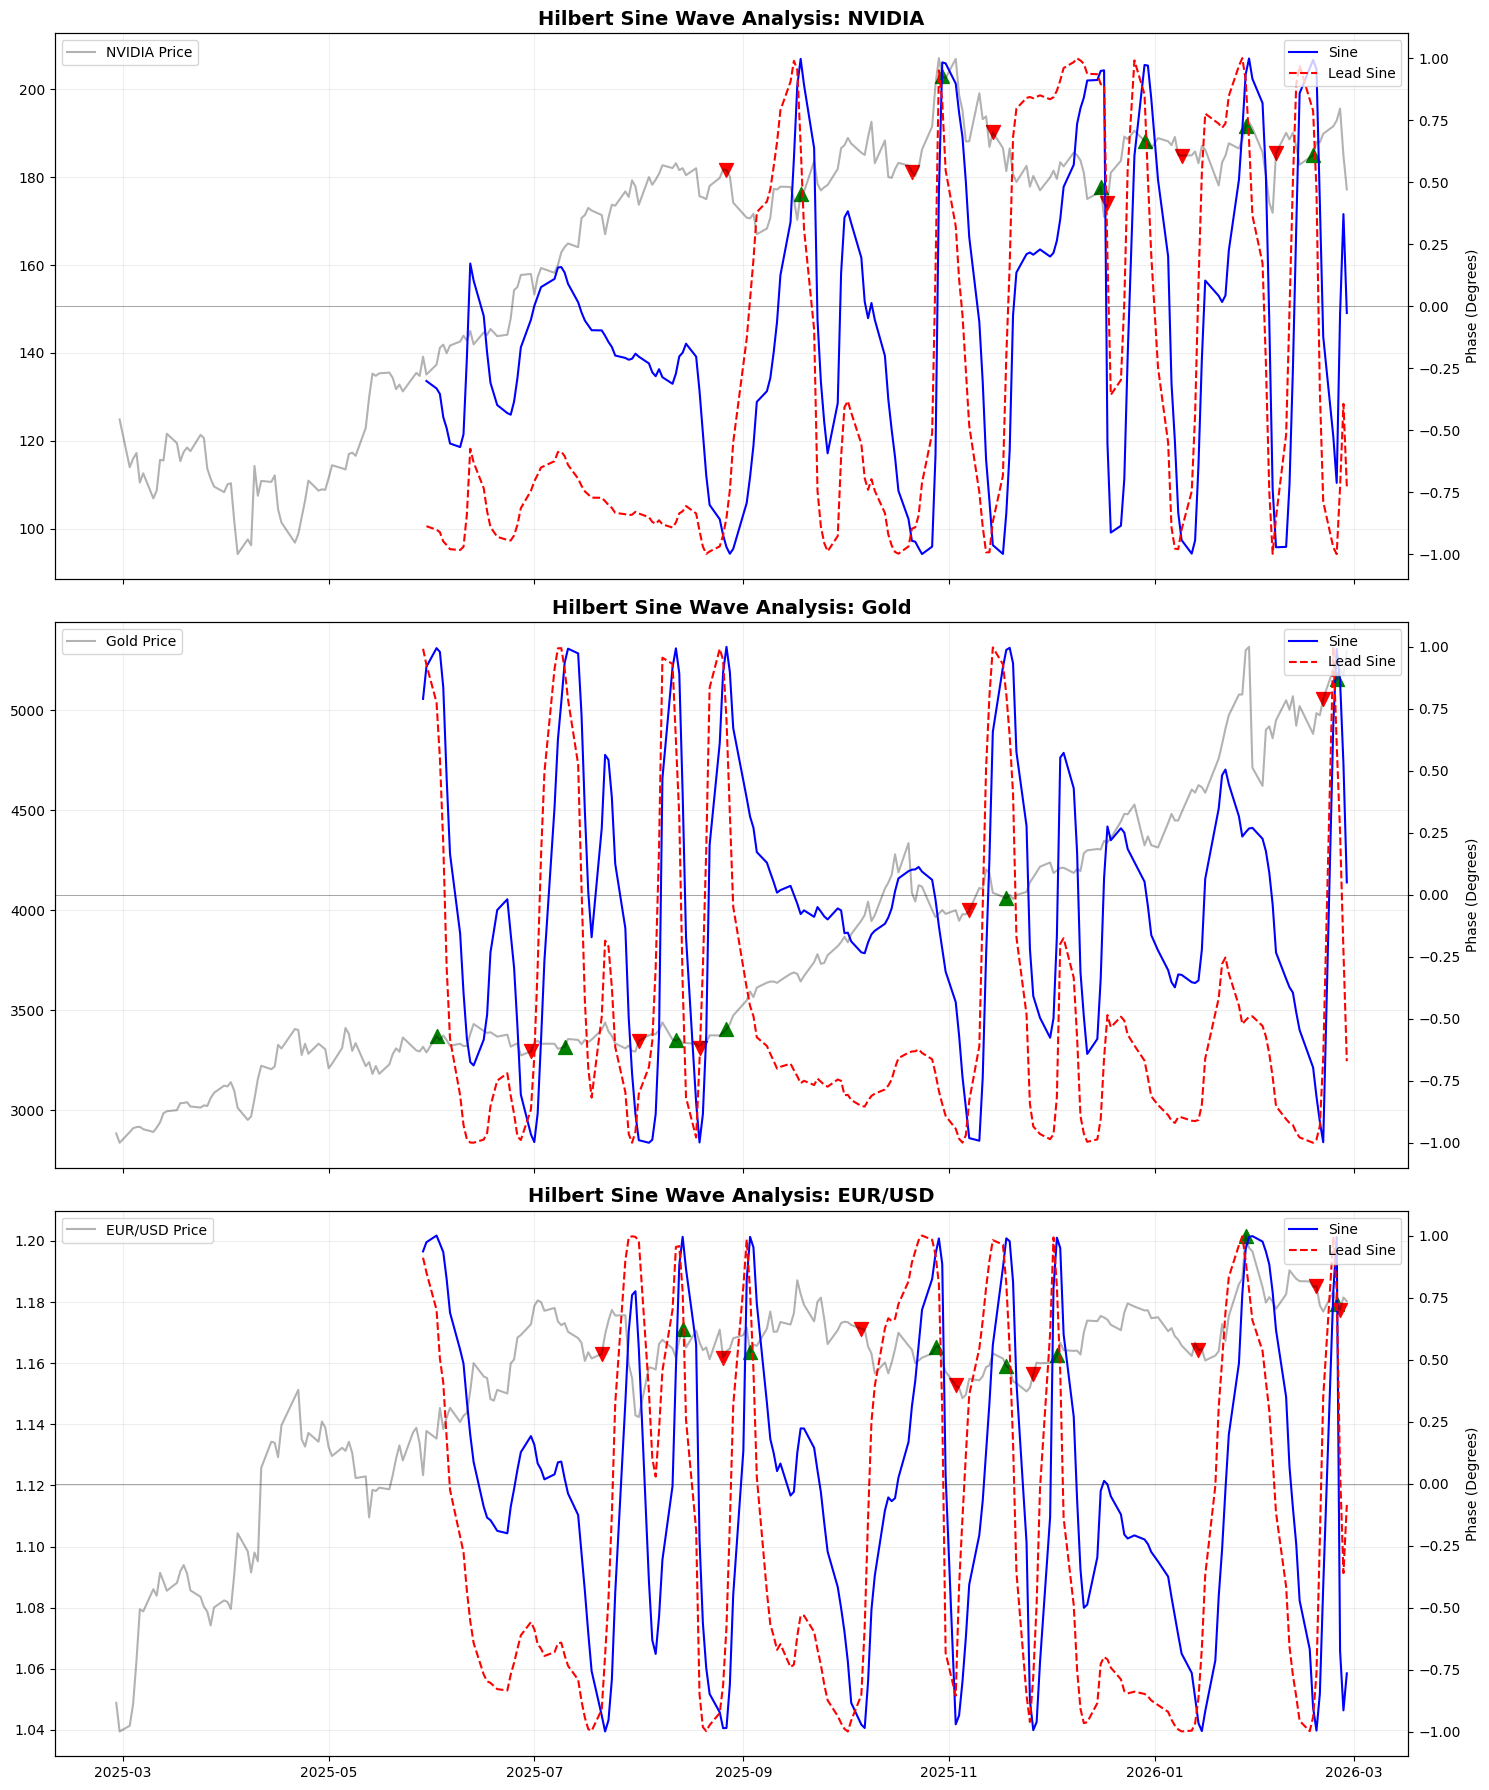

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import talib
import matplotlib.pyplot as plt

# 1. เลือกตัวแทนสินทรัพย์ 3 ประเภท: หุ้นเทค (NVDA), ทองคำ (GC=F), ค่าเงิน (EUR/USD)
plot_tickers = {'NVIDIA': 'NVDA', 'Gold': 'GC=F', 'EUR/USD': 'EURUSD=X'}

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 18), sharex=True)

for i, (name, symbol) in enumerate(plot_tickers.items()):
    # ดึงข้อมูล 1 ปีล่าสุดเพื่อให้กราฟไม่แน่นเกินไป
    df = yf.download(symbol, period='1y', interval='1d', auto_adjust=True)

    # จัดการ MultiIndex ของ yfinance
    if isinstance(df.columns, pd.MultiIndex):
        close = df['Close'][symbol].values.flatten()
    else:
        close = df['Close'].values.flatten()

    # 2. คำนวณ Hilbert Sine Wave
    sine, leadsine = talib.HT_SINE(close)

    # 3. พล็อตกราฟราคา (ด้านบนของแต่ละ Subplot)
    ax_price = axes[i]
    ax_price.plot(df.index, close, label=f'{name} Price', color='black', alpha=0.3)
    ax_price.set_title(f'Hilbert Sine Wave Analysis: {name}', fontsize=14, fontweight='bold')
    ax_price.legend(loc='upper left')

    # 4. พล็อตกราฟ Sine Wave (ด้านล่างซ้อนกัน - Twin Axis)
    ax_sine = ax_price.twinx()
    ax_sine.plot(df.index, sine, label='Sine', color='blue', linewidth=1.5)
    ax_sine.plot(df.index, leadsine, label='Lead Sine', color='red', linestyle='--', linewidth=1.5)
    ax_sine.axhline(0, color='black', linewidth=0.5, alpha=0.5)

    # สร้างจุด Buy/Sell Signals (Sine ตัด Lead Sine)
    buy_sig = (sine > leadsine) & (np.roll(sine, 1) <= np.roll(leadsine, 1))
    sell_sig = (sine < leadsine) & (np.roll(sine, 1) >= np.roll(leadsine, 1))

    # มาร์คจุดบนกราฟราคา
    ax_price.scatter(df.index[buy_sig], close[buy_sig], marker='^', color='green', s=100, label='Buy')
    ax_price.scatter(df.index[sell_sig], close[sell_sig], marker='v', color='red', s=100, label='Sell')

    ax_sine.set_ylabel('Phase (Degrees)')
    ax_sine.legend(loc='upper right')
    ax_price.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:

tickers = {
    'NVIDIA': 'NVDA', 'Gold': 'GC=F',
    'Apple': 'AAPL', 'EUR/USD': 'EURUSD=X','GBP/USD': 'GBPUSD=X'
}

results = []

for name, symbol in tickers.items():
    df = yf.download(symbol, period='2y', interval='1d', auto_adjust=True)

    # ดึงราคาปิด (จัดการ MultiIndex)
    if isinstance(df.columns, pd.MultiIndex):
        close = df['Close'][symbol].values.flatten()
        high = df['High'][symbol].values.flatten()
        low = df['Low'][symbol].values.flatten()
    else:
        close = df['Close'].values.flatten()
        high = df['High'].values.flatten()
        low = df['Low'].values.flatten()

    # 1. คำนวณ Hilbert Sine Wave
    sine, leadsine = talib.HT_SINE(close)

    # 2. คำนวณ ADX (เช็คความแรงของเทรนด์)
    adx = talib.ADX(high, low, close, timeperiod=14)

    # 3. สร้าง Strategy Logic
    df['Signal'] = 0
    # เริ่มเช็คตั้งแต่จุดที่มีข้อมูลครบ (ADX ต้องการ 28-30 วัน)
    for t in range(30, len(df)):
        # ถ้า ADX > 25 (Strong Trend) -> เกาะเทรนด์ (Hold)
        if adx[t] > 25:
            df.iloc[t, df.columns.get_loc('Signal')] = 1
        # ถ้า ADX <= 25 (Sideway/Cycle) -> เทรดตาม Hilbert Sine Wave
        else:
            if sine[t] > leadsine[t]:
                df.iloc[t, df.columns.get_loc('Signal')] = 1
            else:
                df.iloc[t, df.columns.get_loc('Signal')] = 0

    # 4. คำนวณ Backtest
    df['Market_Ret'] = df['Close'].pct_change()
    df['Strategy_Ret'] = df['Market_Ret'] * df['Signal'].shift(1)

    cum_strategy = (1 + df['Strategy_Ret'].fillna(0)).cumprod().iloc[-1] - 1
    cum_market = (1 + df['Market_Ret'].fillna(0)).cumprod().iloc[-1] - 1

    results.append({
        'Asset': name,
        'Buy & Hold (%)': round(cum_market * 100, 2),
        'Hilbert+ADX (%)': round(cum_strategy * 100, 2)
    })

# แสดงผลเปรียบเทียบ
summary = pd.DataFrame(results)
print("\n--- Backtest Result: Hilbert + ADX Filter ---")
print(summary.to_string(index=False))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



--- Backtest Result: Hilbert + ADX Filter ---
  Asset  Buy & Hold (%)  Hilbert+ADX (%)
 NVIDIA          128.28            36.17
   Gold          160.39           101.94
  Apple           46.94            36.11
EUR/USD            8.77             2.65
GBP/USD            6.36            -0.16
